# Disease Prediction using Logistic Regression

**Dataset:** `Blood_samples_dataset_balanced_2_f_.csv`
2,351 patient blood-test records, 24 numeric lab features (pre-normalized to a 0–1 range), and a target column `Disease` with 5 classes: **Healthy, Diabetes, Anemia, Thalassemia (Thalasse), Thrombocytopenia (Thromboc)**.

**Goal:** Train a multinomial logistic regression model that predicts the disease class from a patient's blood panel, evaluate it thoroughly, and export the trained model for use in a live dashboard.

**Pipeline:**
1. Load & inspect the data
2. Exploratory Data Analysis (EDA)
3. Preprocessing (encode target, scale features, train/test split)
4. Train a Logistic Regression model
5. Evaluate (accuracy, confusion matrix, classification report, ROC curves)
6. Interpret feature importance
7. Save the model + preprocessing artifacts for the dashboard


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

ASSETS = "assets"
MODELS = "models"
os.makedirs(ASSETS, exist_ok=True)
os.makedirs(MODELS, exist_ok=True)

## 2. Load & Inspect the Data

In [2]:
df = pd.read_csv("data/Blood_samples_dataset_balanced_2_f_.csv")
print("Shape:", df.shape)
df.head()

Shape: (2351, 25)


,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2351 entries, 0 to 2350
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Glucose                                    2351 non-null   float64
 1   Cholesterol                                2351 non-null   float64
 2   Hemoglobin                                 2351 non-null   float64
 3   Platelets                                  2351 non-null   float64
 4   White Blood Cells                          2351 non-null   float64
 5   Red Blood Cells                            2351 non-null   float64
 6   Hematocrit                                 2351 non-null   float64
 7   Mean Corpuscular Volume                    2351 non-null   float64
 8   Mean Corpuscular Hemoglobin                2351 non-null   float64
 9   Mean Corpuscular Hemoglobin Concentration  2351 non-null   float64
 10  Insulin                            

In [4]:
# Check for missing values and basic stats
print("Total missing values:", df.isnull().sum().sum())
df.describe().T[["min", "max", "mean", "std"]]

Total missing values: 0


,min,max,mean,std
Glucose,0.010994,0.968460,0.362828,0.251889
Cholesterol,0.012139,0.905026,0.393648,0.239449
Hemoglobin,0.003021,0.983306,0.586190,0.271498
Platelets,0.012594,0.999393,0.504027,0.303347
White Blood Cells,0.010139,0.990786,0.511086,0.277270
Red Blood Cells,0.044565,1.000000,0.506590,0.266565
Hematocrit,0.011772,0.977520,0.507152,0.285537
Mean Corpuscular Volume,0.046942,0.995263,0.492200,0.275735
Mean Corpuscular Hemoglobin,0.000554,0.963235,0.484459,0.315618
Mean Corpuscular Hemoglobin Concentration,0.006947,0.975586,0.562273,0.273281


In [5]:
FEATURE_COLS = [c for c in df.columns if c != "Disease"]
TARGET_COL = "Disease"
print(f"{len(FEATURE_COLS)} feature columns")
print(FEATURE_COLS)

24 feature columns
['Glucose', 'Cholesterol', 'Hemoglobin', 'Platelets', 'White Blood Cells', 'Red Blood Cells', 'Hematocrit', 'Mean Corpuscular Volume', 'Mean Corpuscular Hemoglobin', 'Mean Corpuscular Hemoglobin Concentration', 'Insulin', 'BMI', 'Systolic Blood Pressure', 'Diastolic Blood Pressure', 'Triglycerides', 'HbA1c', 'LDL Cholesterol', 'HDL Cholesterol', 'ALT', 'AST', 'Heart Rate', 'Creatinine', 'Troponin', 'C-reactive Protein']


## 3. Exploratory Data Analysis (EDA)

### 3.1 Class distribution
The dataset is reasonably balanced across the five classes, with `Thromboc` somewhat underrepresented.

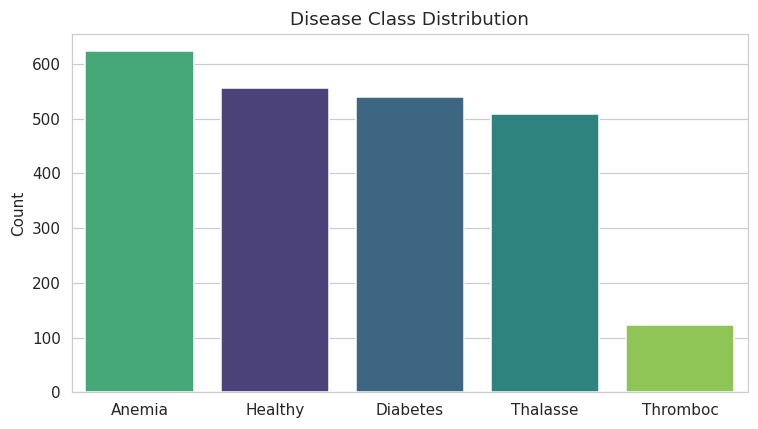

Disease
Anemia      623
Healthy     556
Diabetes    540
Thalasse    509
Thromboc    123
Name: count, dtype: int64

In [6]:
plt.figure(figsize=(7, 4))
order = df[TARGET_COL].value_counts().index
sns.countplot(data=df, x=TARGET_COL, order=order, hue=TARGET_COL, palette="viridis", legend=False)
plt.title("Disease Class Distribution")
plt.xlabel("")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{ASSETS}/class_distribution.png")
plt.show()

df[TARGET_COL].value_counts()

### 3.2 Feature correlation
Some lab values are naturally correlated (e.g. red-blood-cell indices, lipid panel components).

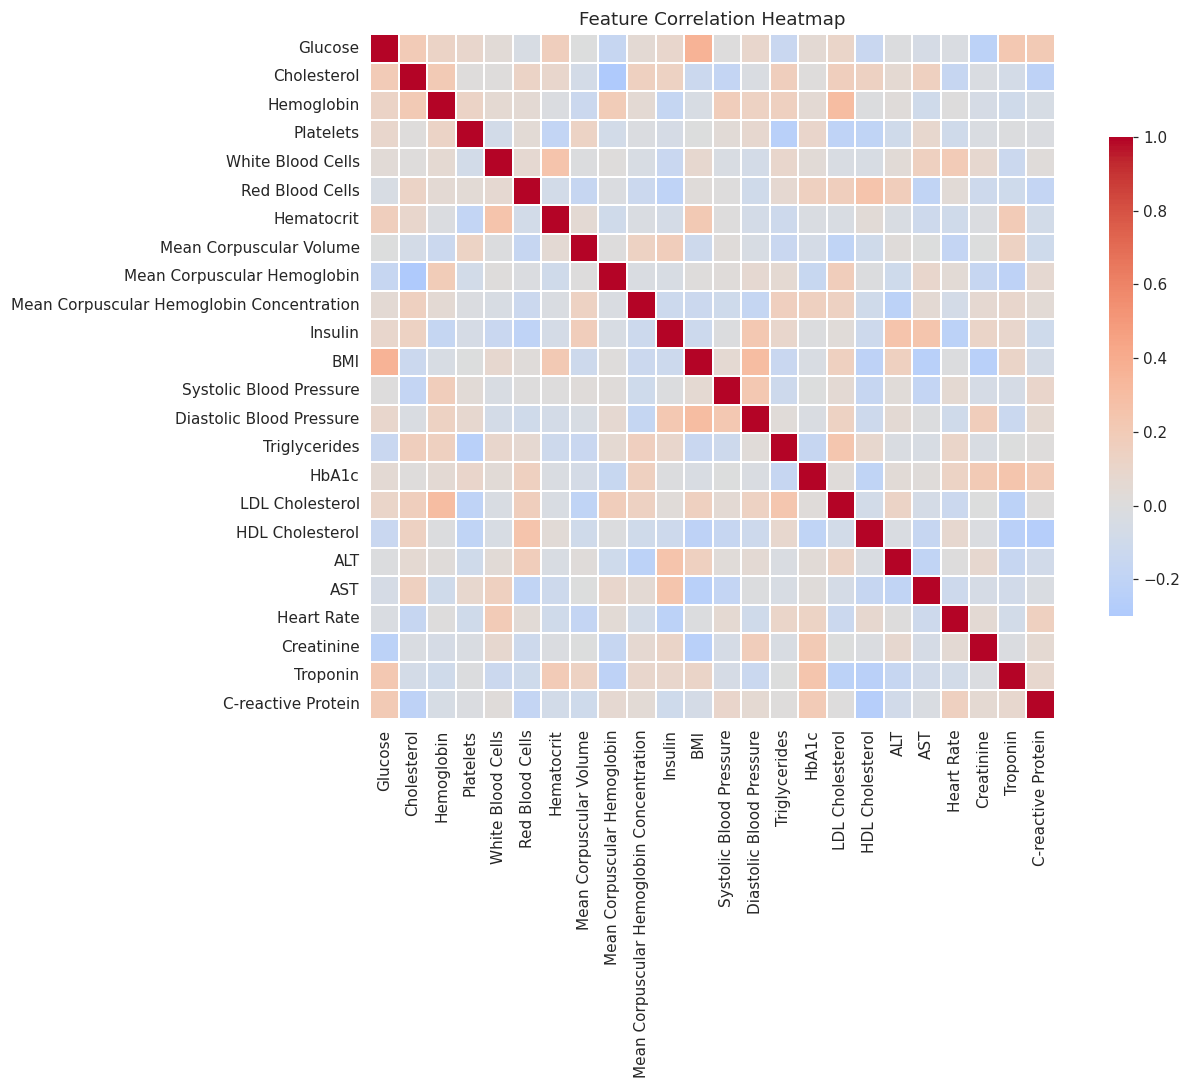

In [7]:
plt.figure(figsize=(13, 10))
corr = df[FEATURE_COLS].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.7})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{ASSETS}/correlation_heatmap.png")
plt.show()

### 3.3 Key feature distributions by disease class
A few clinically relevant markers (Glucose, Hemoglobin, HbA1c, Platelets) already show clear separation between classes — a good sign for a linear model like logistic regression.

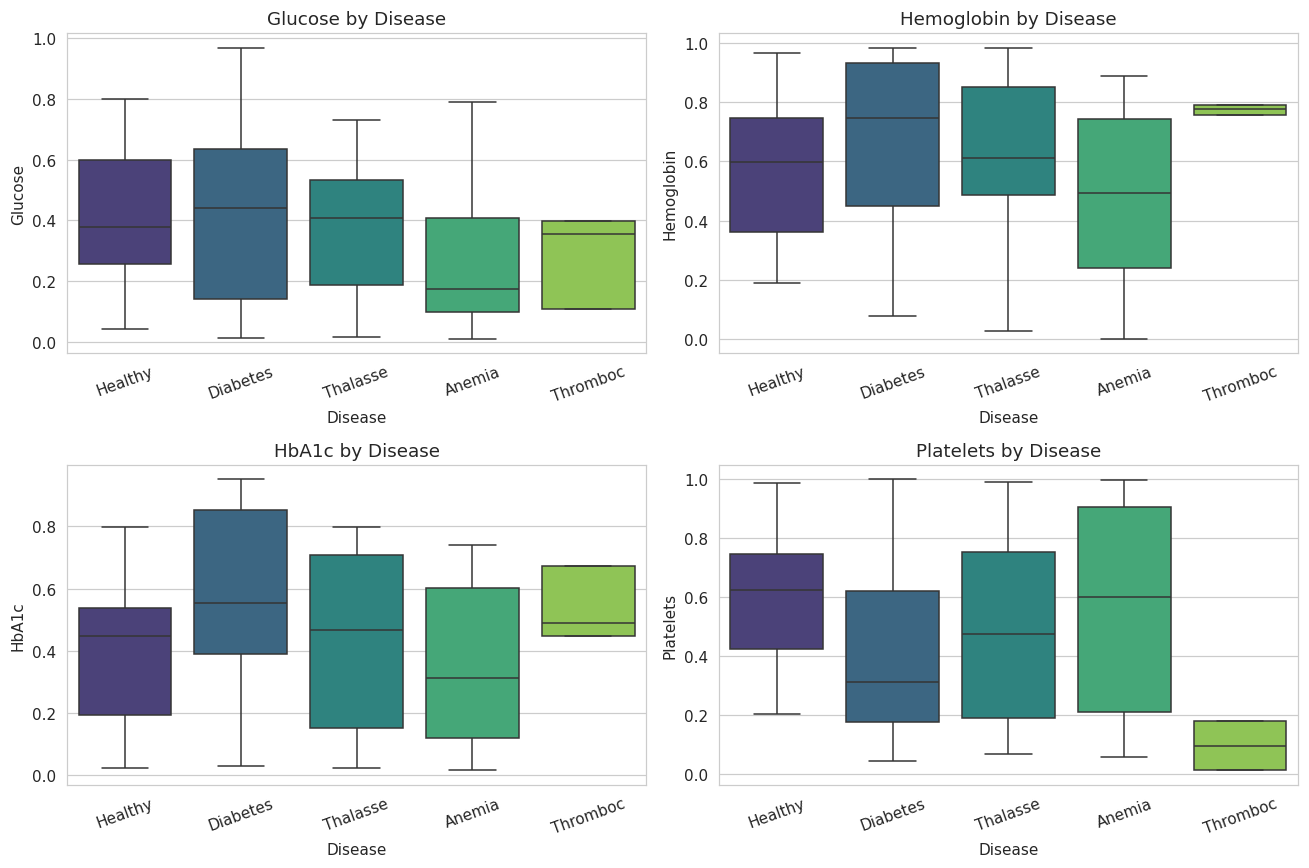

In [8]:
key_feats = ["Glucose", "Hemoglobin", "HbA1c", "Platelets"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flat, key_feats):
    sns.boxplot(data=df, x=TARGET_COL, y=feat, hue=TARGET_COL, ax=ax, palette="viridis", legend=False)
    ax.set_title(f"{feat} by Disease")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.savefig(f"{ASSETS}/feature_distributions.png")
plt.show()

## 4. Preprocessing

- **Encode target:** `Disease` (text) → integer labels via `LabelEncoder`
- **Train/test split:** 80/20, stratified to preserve class proportions
- **Scale features:** `StandardScaler` fit on the training set only (avoids data leakage), even though the raw values are already min-max normalized — logistic regression still benefits from zero-mean/unit-variance inputs for stable optimization.

In [9]:
le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL])
X = df[FEATURE_COLS].values

print("Classes:", dict(zip(le.classes_, range(len(le.classes_)))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Classes: {'Anemia': 0, 'Diabetes': 1, 'Healthy': 2, 'Thalasse': 3, 'Thromboc': 4}
Train size: (1880, 24)  Test size: (471, 24)


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Train the Logistic Regression Model

Using scikit-learn's `LogisticRegression` with the `lbfgs` solver, which natively supports multinomial (softmax) optimization for multi-class problems.

In [11]:
model = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    C=1.0,
    random_state=42,
)
model.fit(X_train_scaled, y_train)
print("Model trained.")

Model trained.


## 6. Model Evaluation

### 6.1 Accuracy & classification report

In [12]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test Accuracy: 1.0000

              precision    recall  f1-score   support

      Anemia       1.00      1.00      1.00       125
    Diabetes       1.00      1.00      1.00       108
     Healthy       1.00      1.00      1.00       111
    Thalasse       1.00      1.00      1.00       102
    Thromboc       1.00      1.00      1.00        25

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471



**Note on the near-perfect score:** this is a clean, balanced *synthetic* dataset where each disease class was generated with distinct, separable blood-marker ranges — so a linear model finds a near-perfect boundary. On real-world clinical data, expect more overlap between classes and correspondingly lower accuracy; treat this score as a property of the dataset, not a guarantee for production use.

### 6.2 Confusion matrix

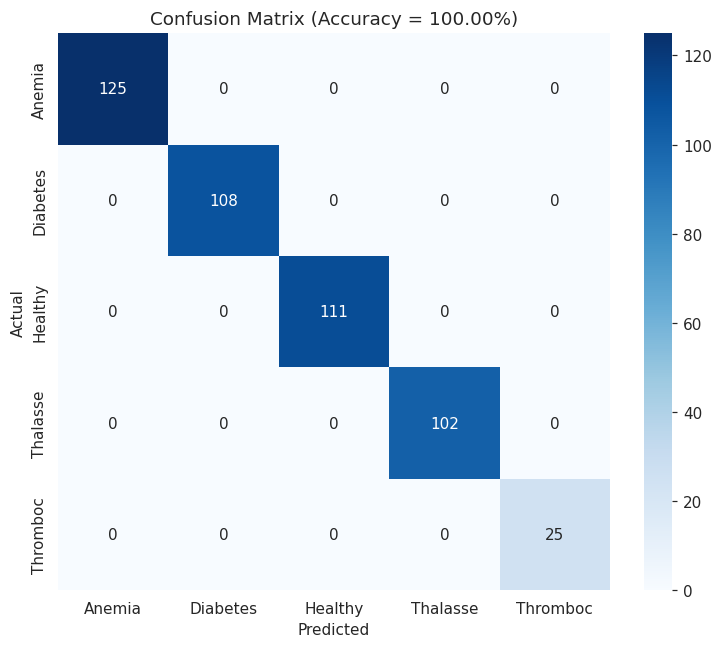

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion Matrix (Accuracy = {acc:.2%})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{ASSETS}/confusion_matrix.png")
plt.show()

### 6.3 ROC curves (One-vs-Rest)
For a multi-class problem, we plot a separate ROC curve per class using the one-vs-rest strategy.

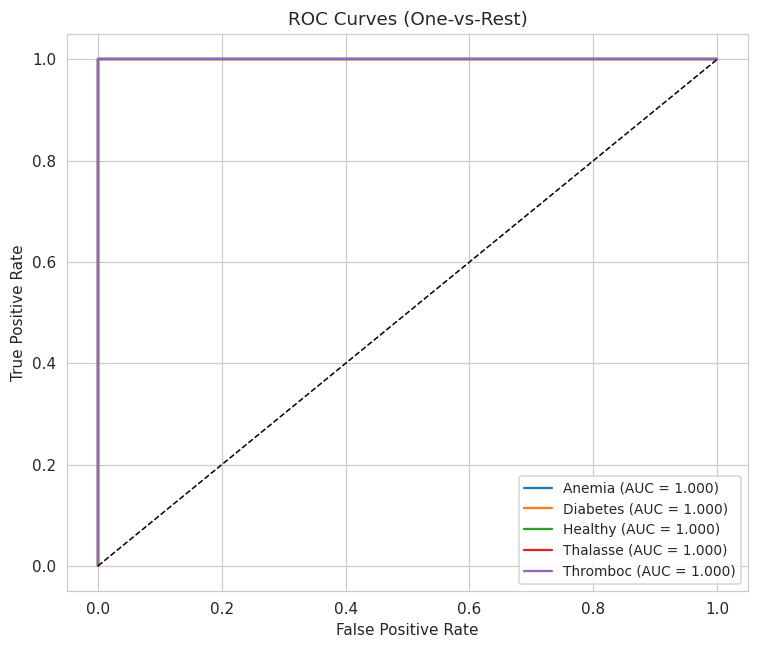

In [14]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
plt.figure(figsize=(7, 6))
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{ASSETS}/roc_curves.png")
plt.show()

## 7. Feature Importance

Logistic regression coefficients indicate how strongly each feature pushes the prediction toward (positive) or away from (negative) a given class. Averaging the absolute coefficient across all five classes gives an overall importance ranking.

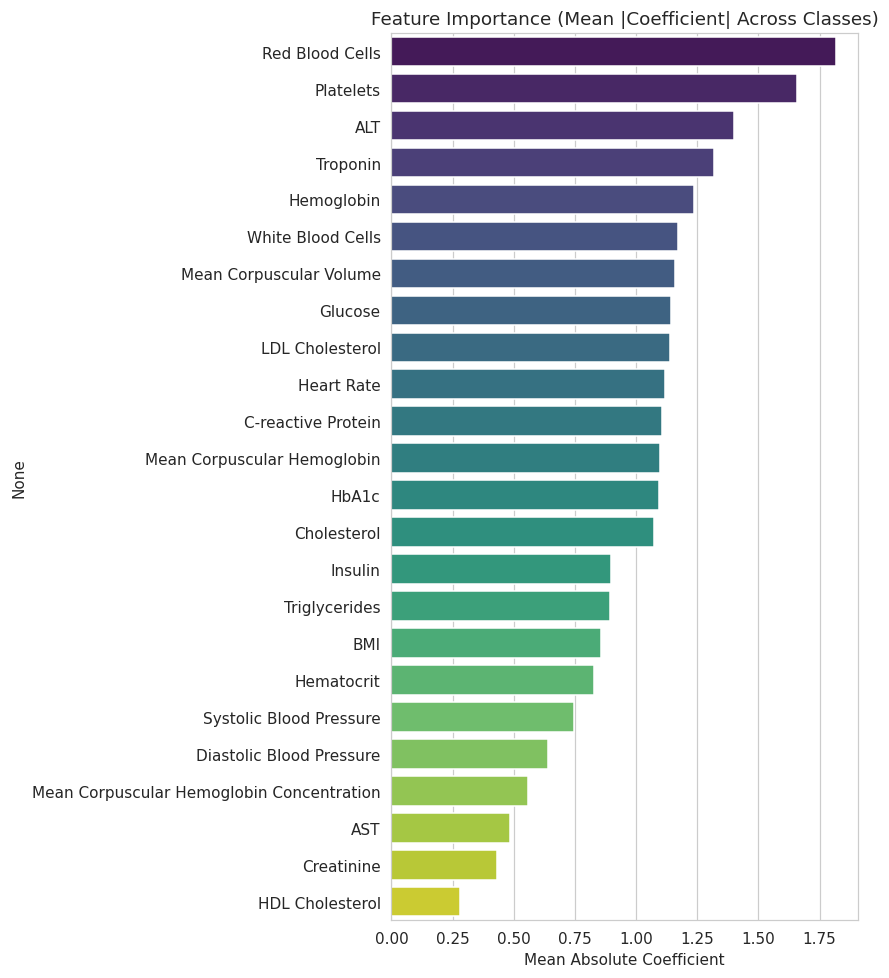

Red Blood Cells            1.816416
Platelets                  1.659917
ALT                        1.400868
Troponin                   1.319012
Hemoglobin                 1.237296
White Blood Cells          1.172503
Mean Corpuscular Volume    1.158753
Glucose                    1.143237
LDL Cholesterol            1.137074
Heart Rate                 1.116747
dtype: float64

In [15]:
coef_df = pd.DataFrame(model.coef_, columns=FEATURE_COLS, index=le.classes_)
importance = coef_df.abs().mean(axis=0).sort_values(ascending=False)

plt.figure(figsize=(8, 9))
sns.barplot(x=importance.values, y=importance.index, hue=importance.index, palette="viridis", legend=False)
plt.title("Feature Importance (Mean |Coefficient| Across Classes)")
plt.xlabel("Mean Absolute Coefficient")
plt.tight_layout()
plt.savefig(f"{ASSETS}/feature_importance.png")
plt.show()

importance.head(10)

## 8. Save Model & Preprocessing Artifacts

These files are loaded directly by the Streamlit dashboard (`app.py`) to make live predictions.

In [16]:
joblib.dump(model, f"{MODELS}/logistic_regression_model.pkl")
joblib.dump(scaler, f"{MODELS}/scaler.pkl")
joblib.dump(le, f"{MODELS}/label_encoder.pkl")
joblib.dump(FEATURE_COLS, f"{MODELS}/feature_names.pkl")

report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
metrics = {
    "accuracy": acc,
    "classification_report": report,
    "classes": list(le.classes_),
    "feature_importance": importance.to_dict(),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
}
with open(f"{MODELS}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

feature_stats = df[FEATURE_COLS].describe().T[["min", "max", "mean"]].to_dict(orient="index")
with open(f"{MODELS}/feature_stats.json", "w") as f:
    json.dump(feature_stats, f, indent=2)

print("Saved model, scaler, label encoder, feature names, metrics, and feature stats.")

Saved model, scaler, label encoder, feature names, metrics, and feature stats.


## 9. Conclusion

- A multinomial logistic regression model was trained on 24 blood-panel features to classify patients into 5 categories.
- The model achieves very high accuracy on this balanced, synthetic dataset (see note in Section 6.1 about real-world expectations).
- Red Blood Cells, Platelets, ALT, Troponin, and Hemoglobin emerged as the most influential markers overall.
- All trained artifacts are exported to `models/` and consumed live by the companion Streamlit dashboard in `app.py`, which lets a user enter a patient's lab values and see the predicted disease with class probabilities.
